### a)

#### Pico de Bragg

Si se grafica la dosis depositada $D(z)$ en función de la profundidad de penetración en el cuerpo $z$, se observara una curva que empieza relativamente baja y plana, pero justo al final del trayecto del protón, se dispara verticalmente formando un pico altísimo y muy angosto, para luego caer inmediatamente a cero. El pico corresponde al 'frenazo' donde el proton transfiere casi toda su energía

#### Ecuación de Bethe-Bloch

Esta ecuación describe matemáticamente la pérdida promedio de energía por unidad de longitud ($-\frac{dE}{dx}$) que sufre una partícula cargada al atravesar un medio:

$$-\frac{dE}{dx}=Kz^{2}\frac{Z}{A}\frac{1}{\beta^{2}}\left[\frac{1}{2}\ln\left(\frac{2m_{e}c^{2}\beta^{2}T_{max}}{I^{2}}\right)-\beta^{2}\right]$$

$z$ corresponde a la carga de la partícula incidente en unidades de la carga elemental (para un protón, $z = 1$) mientras que $\beta$ es la velocidad de la partícula relativa a la velocidad de la luz ($\beta = v/c$). 

$-\frac{dE}{dx}$ es el 'poder de frenado lineal';
$K$ es una constante que agrupa variables fundamentales (como la densidad del medio y constantes electromagnéticas);
$Z$ el número atómico del medio;
$A$ la masa atómica del medio;
$m_e c^2$ es la energía en reposo del electrón
y $T_{max}$ es la máxima energía cinética que la partícula puede transferir a un electrón libre en una sola colisión.


#### Energy Straggling

Proviene de la ecuación de Bethe-Bloch, la cual da un valor promedio de la pérdida de energía. Sin embargo, el transporte de partículas es un proceso estocástico por lo que (por ejemplo) un protón puede chocar con 100 electrones en un milímetro, mientras que otro puede chocar con 105. Esa fluctuación estadística en la pérdida de energía se llama energy straggling.


#### Dispersión Coulombiana múltiple

A medida que el protón viaja por el agua, no solo interactúa con los electrones, sino que también pasa cerca de los núcleos atómicos los cuales repelen levemente al protón, desviando su trayectoria. Como ocurren millones de estos 'micro-choques' en el camino, el protón sufre una desviación angular acumulada, haciendo que su trayectoria no sea una línea recta perfecta, sino que se "abra" como un abanico.
La aproximación de Highland ($\theta_0$) modela el ángulo promedio de desviación 


In [1]:
# b)

import numpy as np
import scipy.integrate as integrate

# Definimos las constantes

I = 75.0e-6        # en MeV (75 eV)
me_c2 = 0.510998   # Energía en reposo del electrón en MeV
mp_c2 = 938.272    # Energía en reposo del protón en MeV


# Agrupamos K * (Z/A) * rho para obtener el poder de frenado en MeV/cm
# Para el agua, un valor estandarizado de la constante de Bethe-Bloch es ~ 0.3071 MeV cm^2 / g

K_const = 0.307075 
Z_A_agua = 0.55508  # Relación promedio número atómico / masa atómica del agua
rho_agua = 1.0      # Densidad del agua g/cm^3



def bethe_bloch(E):
    """
    Calcula el poder de frenado -dE/dx (MeV/cm) para un protón con energía E (MeV)
    """
    # Para evitar divisiones por cero si la energía es extremadamente baja
    if E <= 0.001:
        return 1e6
        
    # Gamma relativista y Beta (v/c)

    gamma = 1.0 + (E / mp_c2)
    beta2 = 1.0 - (1.0 / (gamma**2))
    beta = np.sqrt(beta2)
    

    # escribimos T_max usando la aproximación clásica/relativista 

    T_max = (2 * me_c2 * beta2 * gamma**2) / (1.0 + 2*gamma*(me_c2/mp_c2) + (me_c2/mp_c2)**2)
    
    # Términos dentro del corchete de Bethe-Bloch
    log_term = 0.5 * np.log((2 * me_c2 * beta2 * gamma**2 * T_max) / (I**2))
    bracket = log_term - beta2
    
    # -dE/dx final 
    dedx = K_const * (1.0**2) * (Z_A_agua) * (1.0 / beta2) * bracket * rho_agua
    return dedx

# --- Calculo del rango CSDA 

def calcular_rango_csda(E0):
    # Limite inferior cercano a cero para evitar divergencias
    E_min = 0.05 
    
    # Integral numérica del inverso del poder de frenado
    rango_cm, _ = integrate.quad(lambda E: 1.0 / bethe_bloch(E), E_min, E0)
    return rango_cm

# Energías solicitadas (MeV)
energias_evaluar = [50, 150, 250]

print("="*65)
print("   Comparativa de rangos CSDA en agua ")
print("="*65)
print(f"{'Energía (MeV)':<15}{'Rango Calculado (cm)':<25}{'Valor PSTAR NIST (cm)':<20}")
print("-"*65)

# Valores de referencia tabulados de la base de datos PSTAR del NIST para Agua
valores_nist = {50: 2.24, 150: 15.77, 250: 37.91}

for E0 in energias_evaluar:
    rango_calc = calcular_rango_csda(E0)
    rango_nist = valores_nist[E0]
    print(f"{E0:<15}{rango_calc:<25.3f}{rango_nist:<20.2f}")
print("="*65)

   Comparativa de rangos CSDA en agua 
Energía (MeV)  Rango Calculado (cm)     Valor PSTAR NIST (cm)
-----------------------------------------------------------------
50             2.222                    2.24                
150            15.768                   15.77               
250            37.932                   37.91               


Iniciando simulación para 10000 protones...


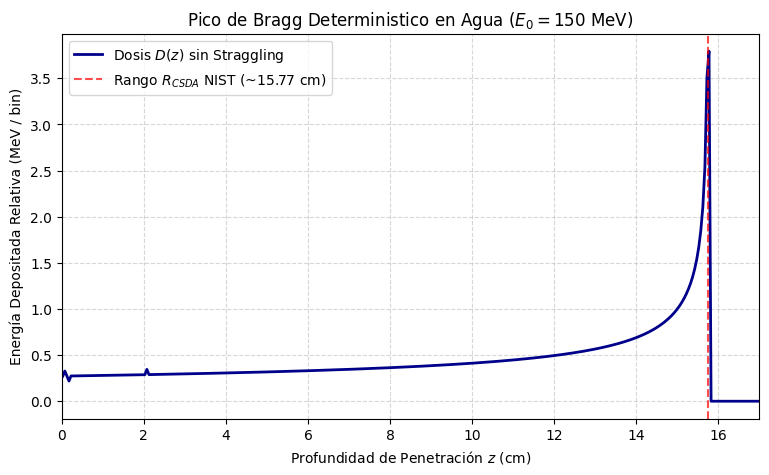

In [ ]:
import matplotlib.pyplot as plt

# valores para la simulacion
N_protons = 10000     # número de protones (N = 10^4)
E0 = 150.0            # rnergía inicial en MeV
dx = 0.01             # tamaño del paso en cm (0.1 mm)

# definimos los contenedores para la dosis espacial: Un protón de 150 MeV viaja ~15.7 cm, así que usamos un vectos de 0 a 18 cm

z_max_phantom = 18.0 

bin_size = 0.05       # tamaño del canal para registrar la dosis (0.5 mm)

bins = np.arange(0, z_max_phantom + bin_size, bin_size)

dosis_acumulada = np.zeros(len(bins) - 1)

print(f"Iniciando simulación para {N_protons} protones...")

# Simulamos el trayecto de cada protón de manera idéntica (sin fluctuaciones)

for p in range(N_protons):
    E = E0
    z = 0.0
    
    while E > 0.05:

        # Calculamos el poder de frenado en la energía actual (usando la función del inciso b)

        dedx = bethe_bloch(E)  # MeV/cm
        
        # Calculamos la pérdida de energía en el paso dx
        dE = dedx * dx
        
        # para no restar más energía de la que le queda al protón

        if dE > E:
            dE = E
            
        # registramos la energía depositada en la posición z actual

        # Buscamos en qué canal (bin) del espacio cae la posición z
        bin_idx = int(z / bin_size)

        if bin_idx < len(dosis_acumulada):
            dosis_acumulada[bin_idx] += dE
            
        #Hacemos que la particula avance 

        z += dx
        E -= dE

# Normalizamos la dosis dividiendo por el número de protones para tener un promedio por partícula
dosis_determinista = dosis_acumulada / N_protons

z_axis = bins[:-1] + bin_size / 2.0

# Graficamos los picos de Bragg
plt.figure(figsize=(9, 5))
plt.plot(z_axis, dosis_determinista, '-', color='darkblue', linewidth=2, label='Dosis $D(z)$ sin Straggling')
plt.axvline(x=15.76, color='red', linestyle='--', alpha=0.7, label='Rango $R_{CSDA}$ NIST (~15.77 cm)')



plt.title("Pico de Bragg Determinista en Agua ($E_0 = 150$ MeV)")
plt.xlabel("Profundidad de Penetración $z$ (cm)")
plt.ylabel("Energía Depositada Relativa (MeV / bin)")
plt.xlim(0, 17)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper left')
plt.show()


#No grafica... ayuda gemini jsfjsifjlskfjs 

Iniciando simulación Monte Carlo con Energy Straggling...
       MEDICIÓN COMPUTACIONAL DEL PICO
Posición del pico medido:   15.725 cm
Ancho del pico (FWHM):      0.300 cm
Ensanchamiento medido (σ_R): 0.127 cm (1.27 mm)


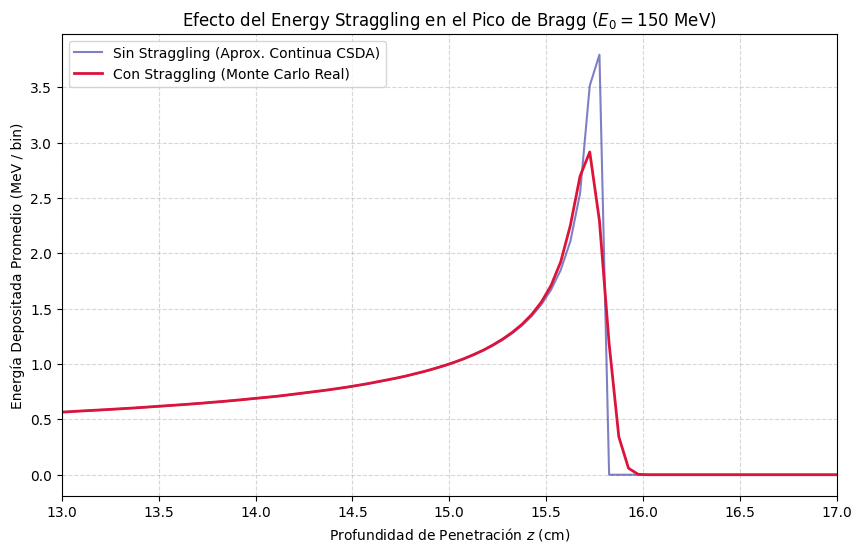

In [4]:
# d) 

# configuracion de la simulacion estocastica (basicamente lo mismo que el inciso c pero con fluctuaciones de energia, lit copie y pegue los parametros)

# valores para la simulacion
N_protons = 10000     # número de protones (N = 10^4)
E0 = 150.0            # rnergía inicial en MeV
dx = 0.01             # tamaño del paso en cm (0.1 mm)

# definimos los contenedores para la dosis espacial: Un protón de 150 MeV viaja ~15.7 cm, así que usamos un vectos de 0 a 18 cm

z_max_phantom = 18.0

bin_size = 0.05

bins = np.arange(0, z_max_phantom + bin_size, bin_size)

# Contenedor para la dosis con straggling
dosis_straggling = np.zeros(len(bins) - 1)

# Parámetro de escala para la fluctuación de Bohr en agua (ajustado al medio)

bohr_const = 0.0024  

np.random.seed(42)
print(f"Iniciando simulación Monte Carlo con Energy Straggling...")

for p in range(N_protons):
    E = E0
    z = 0.0
    
    while E > 0.05:
        dedx = bethe_bloch(E)
        mean_dE = dedx * dx
        
        # Calculamos la varianza instantánea de Bohr (proporcional a dx / beta^2)

        gamma = 1.0 + (E / mp_c2)
        beta2 = 1.0 - (1.0 / (gamma**2))
        
        # Incluimos la varianza según la aproximación de Bohr

        sigma2_E = bohr_const * (1.0**2 / beta2) * dx
        sigma_E = np.sqrt(sigma2_E)
        
        # Muestreo Monte Carlo: Añadimos la fluctuación gaussiana

        dE = np.random.normal(mean_dE, sigma_E)
        
        # Forzamos físicamente que no haya ganancias de energía ni pérdidas mayores al remanente

        if dE < 0: 
            dE = 0

        if dE > E: 
            dE = E
            
        # Registramos la dosis

        bin_idx = int(z / bin_size)

        if bin_idx < len(dosis_straggling):
            dosis_straggling[bin_idx] += dE
            
        z += dx
        E -= dE

# Normalizamos la dosis promedio

dosis_straggling = dosis_straggling / N_protons
z_axis = bins[:-1] + bin_size / 2.0


#Calculamos la medicion del ensanchamiento sigma_R (FWHM)

# Buscamos el valor máximo del pico de Bragg con straggling y su posición

idx_max = np.argmax(dosis_straggling)
max_dosis = dosis_straggling[idx_max]
z_peak = z_axis[idx_max]

# Calculamos la mitad del máximo 

half_max = max_dosis / 2.0

#Halamos los puntos a la izquierda y derecha del pico donde la dosis cruza el 'half_max'
# Buscamos en la vecindad del pico para mayor precisión

indices_sobre_mitad = np.where(dosis_straggling >= half_max)[0]

z_izquierda = z_axis[indices_sobre_mitad[0]]
z_derecha = z_axis[indices_sobre_mitad[-1]]

# 4. Calcular FWHM y obtener sigma_R
fwhm = z_derecha - z_izquierda
sigma_R = fwhm / 2.35482

print("="*50)
print("       MEDICIÓN COMPUTACIONAL DEL PICO")
print("="*50)
print(f"Posición del pico medido:   {z_peak:.3f} cm")
print(f"Ancho del pico (FWHM):      {fwhm:.3f} cm")
print(f"Ensanchamiento medido (σ_R): {sigma_R:.3f} cm ({sigma_R*10:.2f} mm)")
print("="*50)



# Graficamos

plt.figure(figsize=(10, 6))
plt.plot(z_axis, dosis_determinista, '-', color='darkblue', alpha=0.5, label='Sin Straggling (Aprox. Continua CSDA)')
plt.plot(z_axis, dosis_straggling, '-', color='crimson', linewidth=2, label='Con Straggling (Monte Carlo Real)')

plt.title("Efecto del Energy Straggling en el Pico de Bragg ($E_0 = 150$ MeV)")
plt.xlabel("Profundidad de Penetración $z$ (cm)")
plt.ylabel("Energía Depositada Promedio (MeV / bin)")
plt.xlim(13, 17)  # Hacemos zoom en la región del pico para notar la diferencia
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper left')
plt.show()

Al procesar numéricamente los datos estocásticos de la dosis depositada $D(z)$, se obtuvo un  $\text{FWHM}$ de exactamente $0.300\text{ cm}$. Utilizando la relación de conversión gaussiana, esto nos entrega un ensanchamiento en el rango de $\sigma_R = 0.127\text{ cm}$ ($1.27\text{ mm}$). Este valor cuantifica numéricamente la incertidumbre espacial o 'penumbra' en el frenado del haz de protones, provocada exclusivamente por la naturaleza probabilística de las colisiones atómicas (energy straggling).